In [45]:
from dotenv import load_dotenv
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import Tool
import os
import requests
from typing import TypedDict, Annotated
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display
import gradio as gr
from langgraph.checkpoint.memory import MemorySaver
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

In [3]:
load_dotenv(override=True)

True

In [5]:
serper = GoogleSerperAPIWrapper()

In [6]:
serper.run("What is the capital of India?")

"New Delhi is the capital city of India and a part of the National Capital Territory of Delhi (NCT). New Delhi is the seat of all three branches of the ... What's The Capital Of India? Pt.346. 149. Dislike. 8. Share. Video unavailable. This content isn't available. Skip video. The capital of India is New Delhi, where national governance is based. As travelers, explore major cultural and civic attractions in the ... Delhi, a city and union territory, is the national capital of India, located in the north-central part of the country. It consists of two main parts: Old Delhi, ... Thus, in 1911, New Delhi became the capital of India, south of the Old City of Delhi. And then over the years, Delhi expanded, and satellite ... Delhi, officially the National Capital Territory (NCT) of Delhi, is a megacity and a union territory of India containing New Delhi, the capital of India. The capital of India is New Delhi, located in the north-central part of the country to the west of the Yamuna River. 

In [8]:
google_search_tool = Tool(
    name="google_search",
    func=serper.run,
    description="Useful for when you need more information from an online search"
)

In [10]:
google_search_tool.invoke("What is the capital of India?")

"New Delhi is the capital city of India and a part of the National Capital Territory of Delhi (NCT). New Delhi is the seat of all three branches of the ... What's The Capital Of India? Pt.346. 149. Dislike. 8. Share. Video unavailable. This content isn't available. Skip video. What is the Capital of India? Capital City, New Delhi. Capital location, 28 36 N, 77 12 E. Capital - history, the city's name is associated with various myths ... The capital of India is New Delhi, where national governance is based. As travelers, explore major cultural and civic attractions in the ... Thus, in 1911, New Delhi became the capital of India, south of the Old City of Delhi. And then over the years, Delhi expanded, and satellite ... Delhi, a city and union territory, is the national capital of India, located in the north-central part of the country. It consists of two main parts: Old Delhi, ... The capital of India is New Delhi, located in the north-central part of the country to the west of the Yamun

In [13]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """ Send a push notification to the user """
    requests.post(url=pushover_url, data={"token": pushover_token, "user": pushover_user, "message": text})

In [14]:
send_push_notification_tool = Tool(
    name="send_push_notification",
    func=push,
    description="Useful for when you want to send a push notification"
)

In [16]:
send_push_notification_tool.invoke("Hello!")

In [17]:
tools = [google_search_tool, send_push_notification_tool]

In [18]:
tools

[Tool(name='google_search', description='Useful for when you need more information from an online search', func=<bound method GoogleSerperAPIWrapper.run of GoogleSerperAPIWrapper(k=10, gl='us', hl='en', type='search', result_key_for_type={'news': 'news', 'places': 'places', 'images': 'images', 'search': 'organic'}, tbs=None, serper_api_key='a8a84c23b058e3abf19095bb0d03c430ced2e108', aiosession=None)>),
 Tool(name='send_push_notification', description='Useful for when you want to send a push notification', func=<function push at 0x0000018025CD14E0>)]

In [23]:
# Step 1: Define the State class
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [25]:
# Step 2: Start the graph builder with the State class
graph_builder = StateGraph(State)

In [27]:
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools=tools)

In [29]:
# Step 3: Create nodes
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [32]:
# Step 4: Create edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")

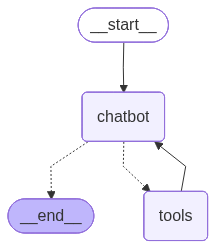

In [34]:
# Step 5: Compile the graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


In [38]:
memory = MemorySaver()

# Step 1: Define State class
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Step 2: Create graph builder with the State class
graph_builder = StateGraph(State)

# Step 3: Create nodes
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools=tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4: Create edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")

# Step 5: Compile graph
graph = graph_builder.compile(checkpointer=memory)

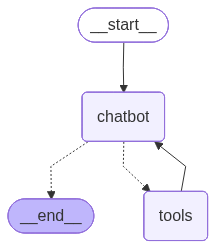

In [39]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='b37f9e63-9919-4952-a494-06967fe5dc46')]}
{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='b37f9e63-9919-4952-a494-06967fe5dc46'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 91, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DNjdOMnxJpxX7LXfBx62NohmVwwbw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--882c1b13-3bad-4cb5-8c50-7a86244c8296-0', usage_metadata={'input_tokens': 91, 'output_tokens': 10, 'total_tokens': 101, 'i

In [43]:
graph.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='b37f9e63-9919-4952-a494-06967fe5dc46'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 91, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DNjdOMnxJpxX7LXfBx62NohmVwwbw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--882c1b13-3bad-4cb5-8c50-7a86244c8296-0', usage_metadata={'input_tokens': 91, 'output_tokens': 10, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMe

In [44]:
list(graph.get_state_history(config=config))

[StateSnapshot(values={'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='b37f9e63-9919-4952-a494-06967fe5dc46'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 91, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DNjdOMnxJpxX7LXfBx62NohmVwwbw', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--882c1b13-3bad-4cb5-8c50-7a86244c8296-0', usage_metadata={'input_tokens': 91, 'output_tokens': 10, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanM

In [56]:
# Setup memory
db_name = "memory.db"
conn = sqlite3.connect(database=db_name, check_same_thread=False)
sql_memory = SqliteSaver(conn=conn)

# Step 1: Define the State class
class State(TypedDict):
    messages: Annotated[list, add_messages]

# Step 2: Create graph builder using the State class
graph_builder = StateGraph(State)

# Step 3: Create nodes
llm = ChatOpenAI(model="gpt-4o-mini")
llm_with_tools = llm.bind_tools(tools=tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Step 4: Create edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")

# Step 5: Compile graph builder
graph = graph_builder.compile(checkpointer=sql_memory)

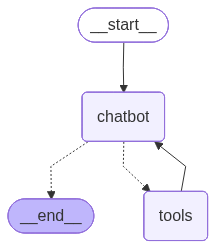

In [52]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "2"}}

def chat(user_inpput: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_inpput}]}, config=config)
    return result["messages"][-1].content

gr.ChatInterface(fn=chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='9c456698-f36d-4c7c-86d9-63206089187c'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 91, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e738e3044b', 'id': 'chatcmpl-DNkB4NViCI1Pl9de2FVI114DoXpIi', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c92bb362-619b-42c7-8ec7-db8797273dff-0', usage_metadata={'input_tokens': 91, 'output_tokens': 10, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(content='My nam

In [58]:
# Close the connection
conn.close()